<a href="https://colab.research.google.com/github/IshitaSharma009/ML/blob/Feature-Engineering/Power_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 /root/.kaggle/kaggle.json

In [2]:
!kaggle datasets download vivekgediya/concrete-data

Dataset URL: https://www.kaggle.com/datasets/vivekgediya/concrete-data
License(s): other
  0% 0.00/11.2k [00:00<?, ?B/s]
100% 11.2k/11.2k [00:00<00:00, 42.2MB/s]


In [4]:
import zipfile
zip_ref=zipfile.ZipFile('concrete-data.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [59]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score


In [10]:
df=pd.read_csv('Concrete_Data.csv')

In [11]:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [35]:
df.rename(columns={
    'Concrete compressive strength(MPa, megapascals) ': 'Strength',
    'Fly Ash (component 3)(kg in a m^3 mixture)': 'FlyAsh',
    'Age (day)': 'Age',
    'Blast Furnace Slag (component 2)(kg in a m^3 mixture)':'Blast Furnace Slag',
    'Water  (component 4)(kg in a m^3 mixture)' : 'Water',
    'Superplasticizer (component 5)(kg in a m^3 mixture)': 'Superplasticizer',
    'Coarse Aggregate  (component 6)(kg in a m^3 mixture)' : 'Coarse Aggregate',
    'Fine Aggregate (component 7)(kg in a m^3 mixture)':'Fine Aggregate',
    'Cement (component 1)(kg in a m^3 mixture)': 'Cement'



}, inplace=True)

In [36]:
df.shape

(1030, 9)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   FlyAsh              1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [38]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
FlyAsh,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


# check wether there are 0's and _ves's

In [39]:
df.describe()

,Cement,Blast Furnace Slag,FlyAsh,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


## ip op extraction

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   FlyAsh              1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [42]:
x=df.drop(columns=['Strength'])

In [43]:
y=df['Strength']

In [44]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [47]:
clf=LinearRegression()

clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)

r2_score(y_pred,y_test)

0.4231704797890976

In [53]:
clf=LinearRegression()
np.mean(cross_val_score(clf,x,y,scoring='r2',cv=10))

np.float64(0.27820729160873814)

In [90]:
x_train.head()

,Cement,Blast Furnace Slag,FlyAsh,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
995,158.6,148.9,116.0,175.1,15.0,953.3,719.7,28
507,424.0,22.0,132.0,178.0,8.5,822.0,750.0,28
334,275.1,0.0,121.4,159.5,9.9,1053.6,777.5,3
848,252.0,97.0,76.0,194.0,8.0,835.0,821.0,28
294,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,3


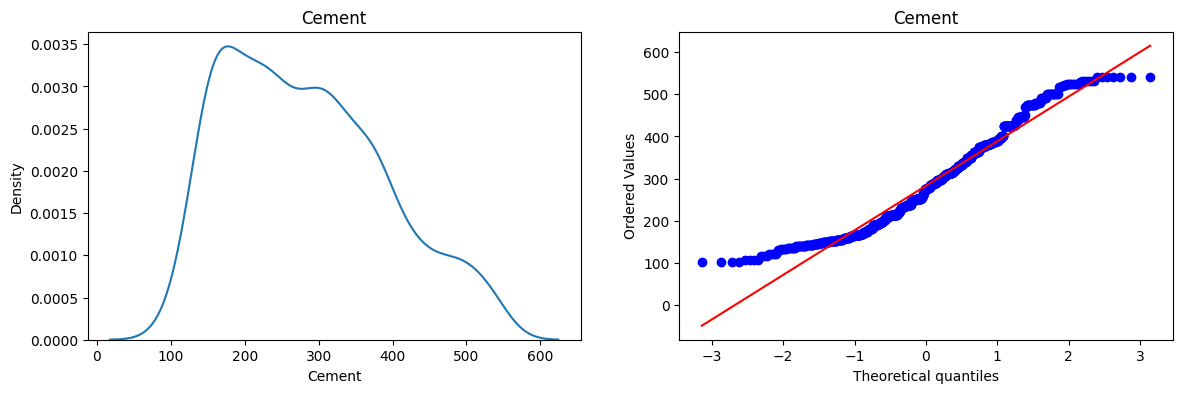

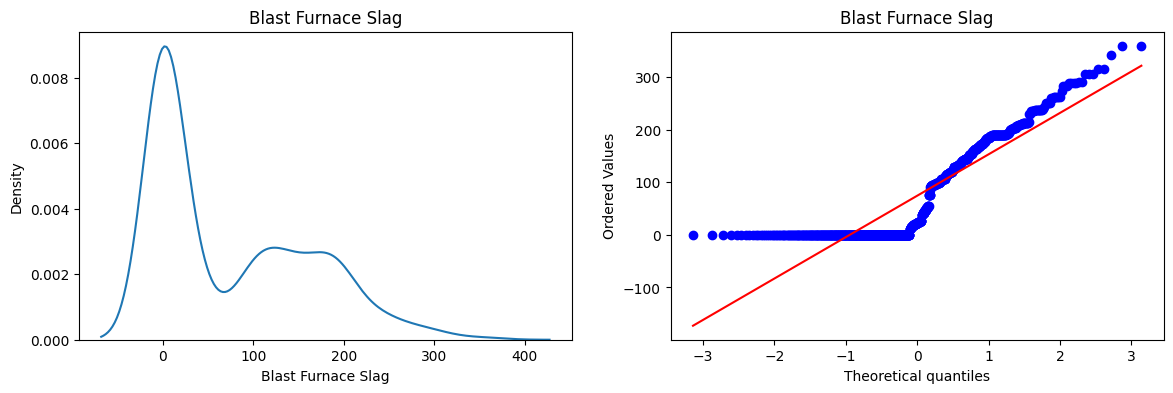

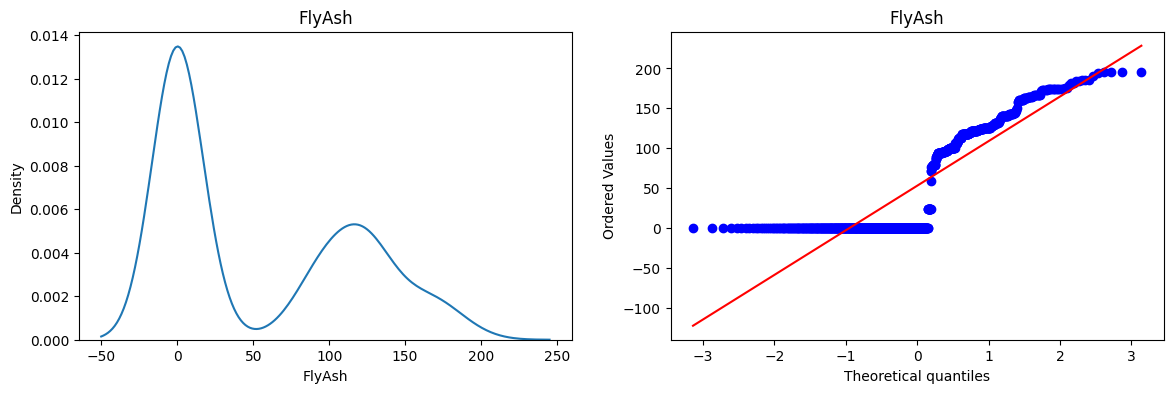

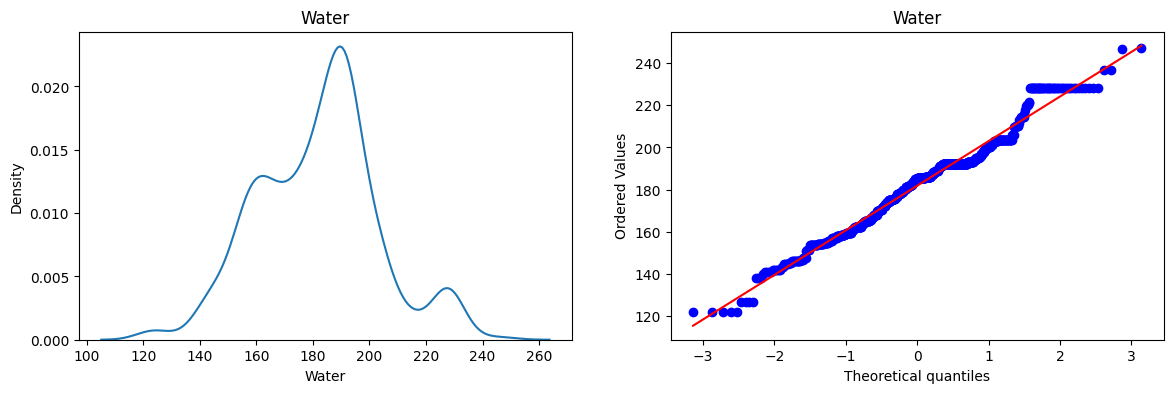

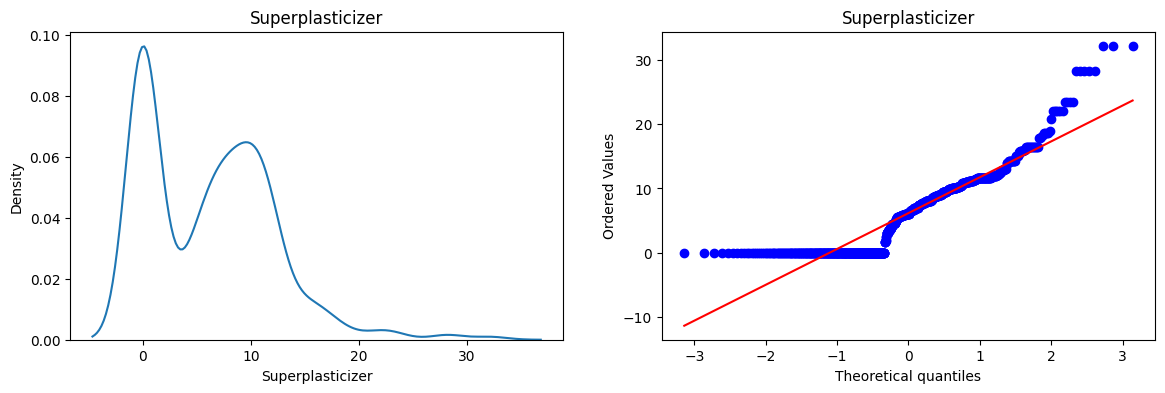

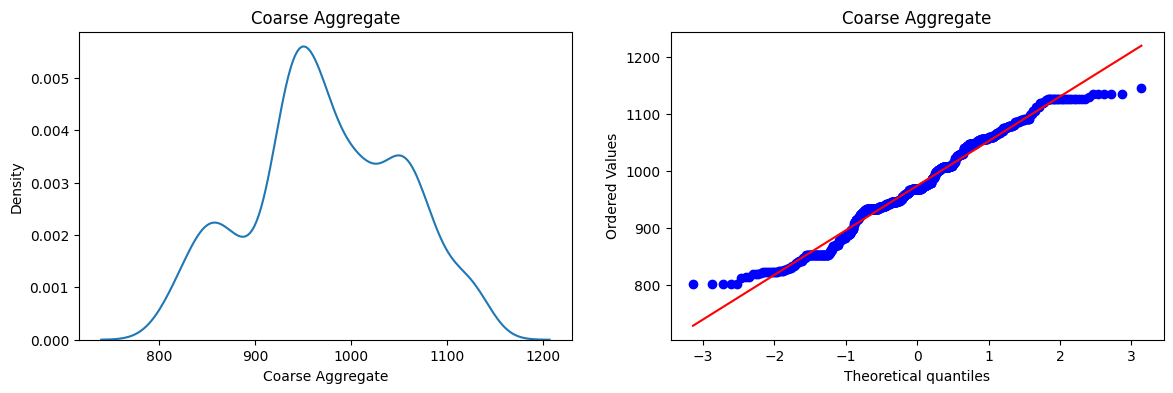

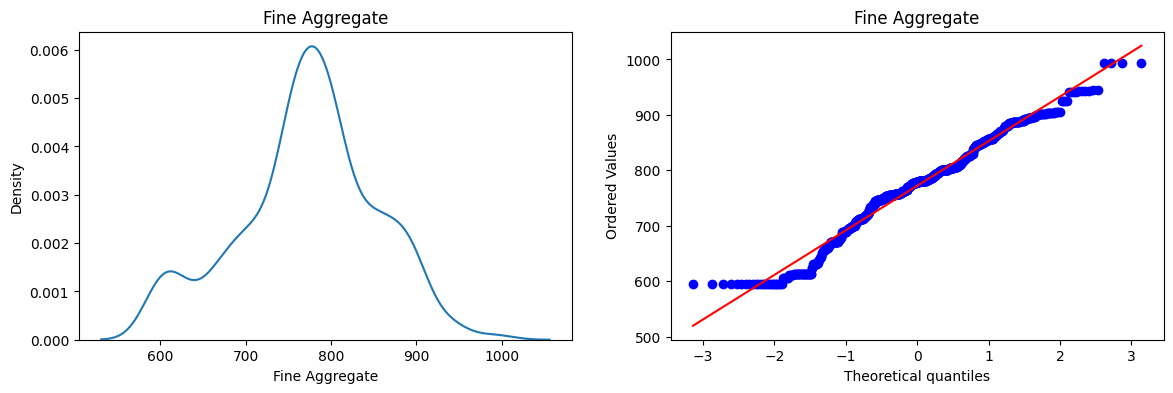

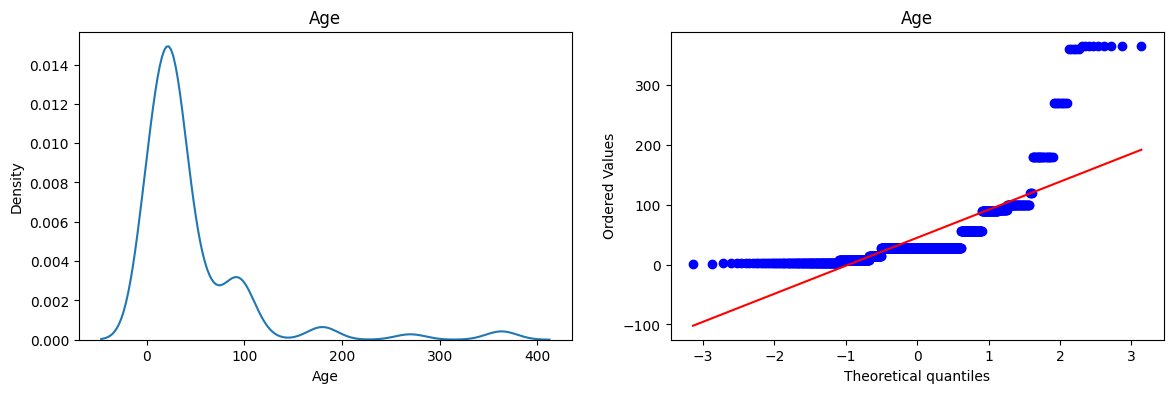

In [57]:
for col in x_train.columns:

  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.kdeplot(x_train[col])
  plt.title(col)

  plt.subplot(122)
  stats.probplot(x_train[col],dist='norm',plot=plt)
  plt.title(col)


In [73]:
pt=PowerTransformer( method='box-cox')

x_new_train=pt.fit_transform(x_train+0.00001)
x_new_test=pt.transform(x_test+0.0001)

pd.DataFrame({'col':x_train.columns,'lambda':pt.lambdas_})

,col,lambda
0,Cement,0.177025
1,Blast Furnace Slag,0.027842
2,FlyAsh,-0.044554
3,Water,0.772682
4,Superplasticizer,0.113892
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066630


In [75]:
clf=LinearRegression()

clf.fit(x_new_train,y_train)
y_pred=clf.predict(x_new_test)

r2_score(y_pred,y_test)


0.7597804992335835

In [78]:
lr=LinearRegression()
np.mean(cross_val_score(lr,x_new_train,y_train,scoring='r2',cv=10))

np.float64(0.7916132325813164)

In [81]:
x_transfromed_train=pd.DataFrame(x_new_train)
x_transfromed_test=pd.DataFrame(x_new_test)

In [91]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824 entries, 995 to 860
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              824 non-null    float64
 1   Blast Furnace Slag  824 non-null    float64
 2   FlyAsh              824 non-null    float64
 3   Water               824 non-null    float64
 4   Superplasticizer    824 non-null    float64
 5   Coarse Aggregate    824 non-null    float64
 6   Fine Aggregate      824 non-null    float64
 7   Age                 824 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 57.9 KB


In [97]:
x_transfromed_train.rename(columns={
    2 : 'FlyAsh',
    7 : 'Age',
    1 :'Blast Furnace Slag',
    3 : 'Water',
    4 : 'Superplasticizer',
    5 : 'Coarse Aggregate',
    6 :'Fine Aggregate',
    0 : 'Cement'
 }, inplace=True)

In [98]:
x_transfromed_train

,Cement,Blast Furnace Slag,FlyAsh,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,-1.279751,0.960702,1.128203,-0.301920,0.919073,-0.262500,-0.677568,0.106010
1,1.244706,0.672998,1.139074,-0.165055,0.745745,-1.912728,-0.314062,0.106010
2,0.079842,-1.084755,1.132038,-1.047291,0.791178,1.018407,0.025957,-1.675970
3,-0.145641,0.894884,1.092185,0.581224,0.727899,-1.750779,0.583253,0.106010
4,-1.131044,0.769285,1.134025,-1.105297,0.817461,1.368575,0.262623,-1.675970
...,...,...,...,...,...,...,...,...
819,0.183601,1.007172,-0.887164,-1.769923,0.828524,0.390563,0.358776,-1.675970
820,-0.198733,-1.084755,1.134565,-1.839129,0.849638,1.445973,0.322797,-0.475625
821,-0.844517,-1.084755,1.134632,-0.706089,0.791178,1.345367,0.297157,1.246733
822,1.565623,0.925921,-0.887164,-0.019311,0.759365,-1.537255,0.076211,0.106010


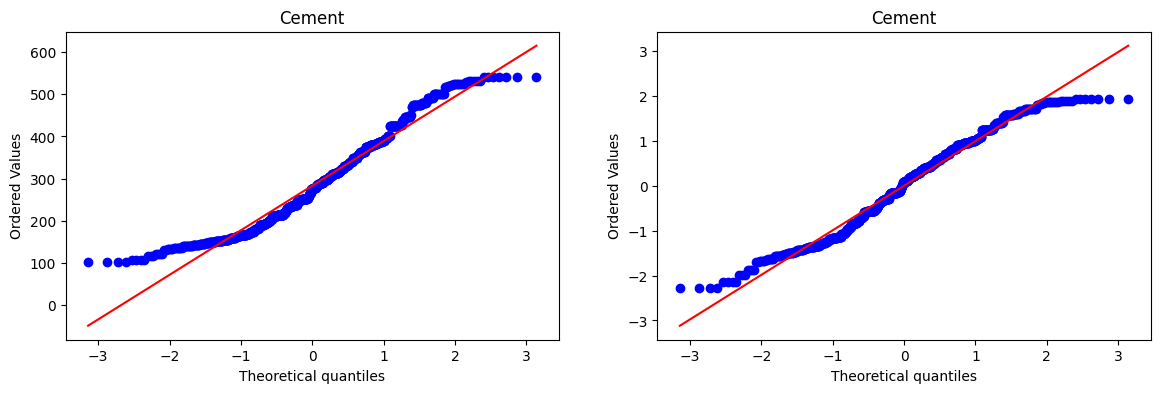

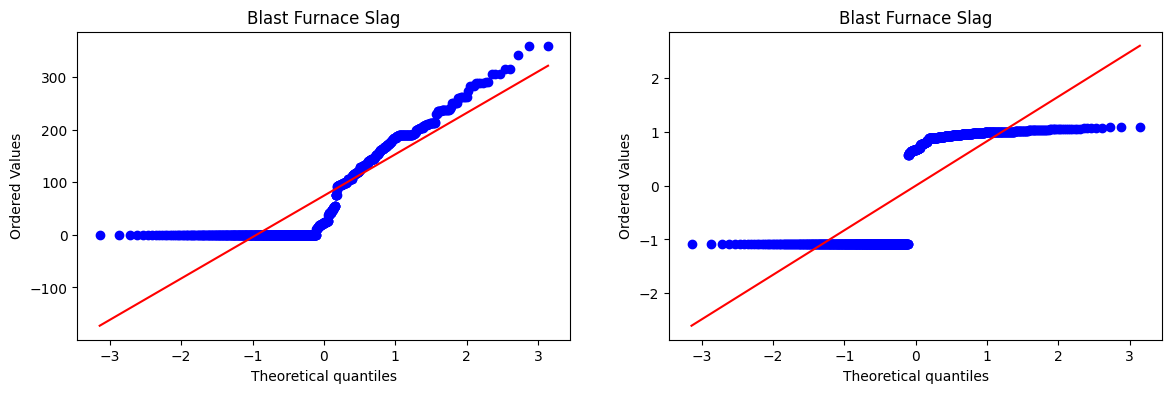

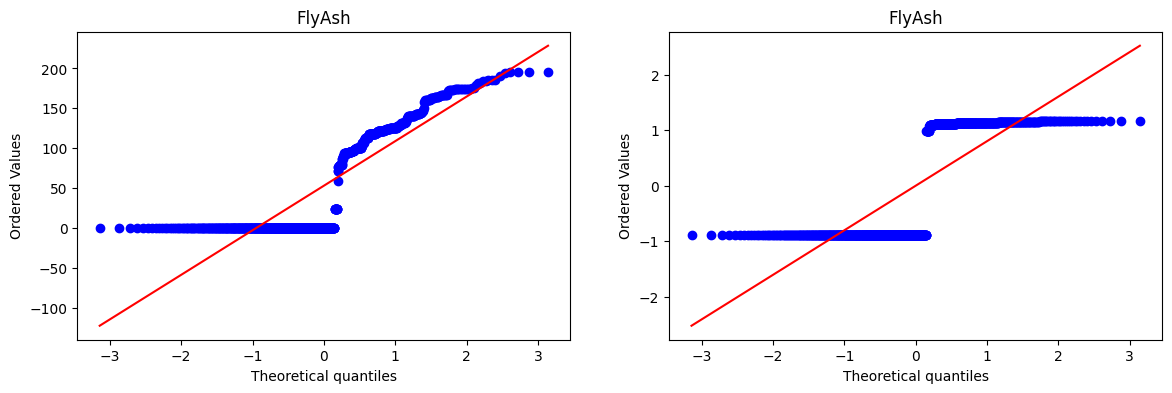

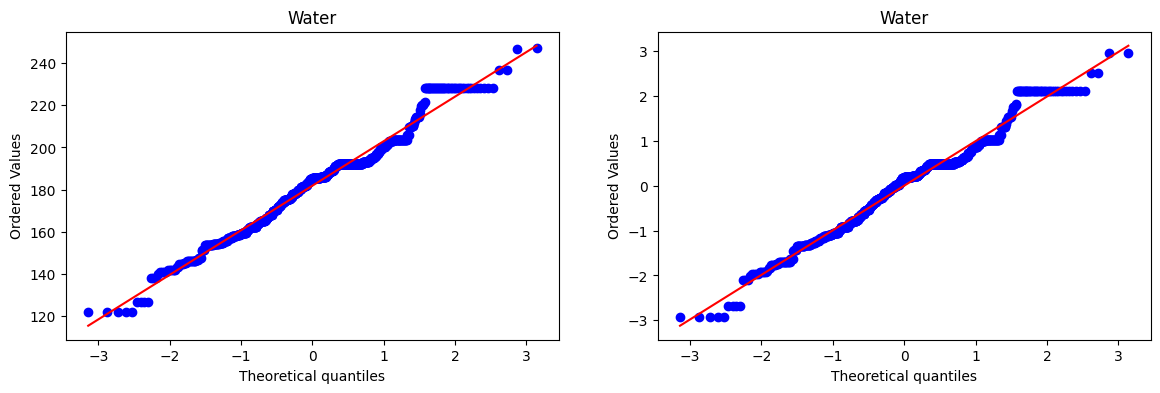

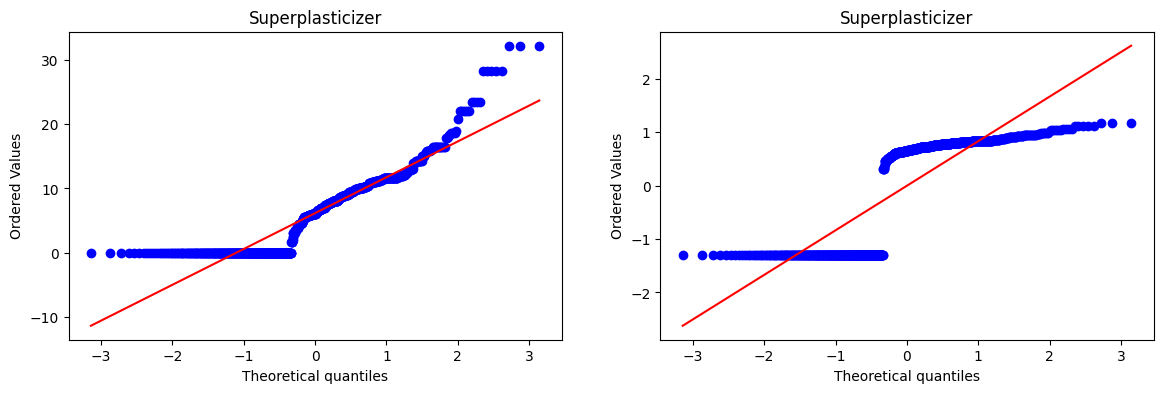

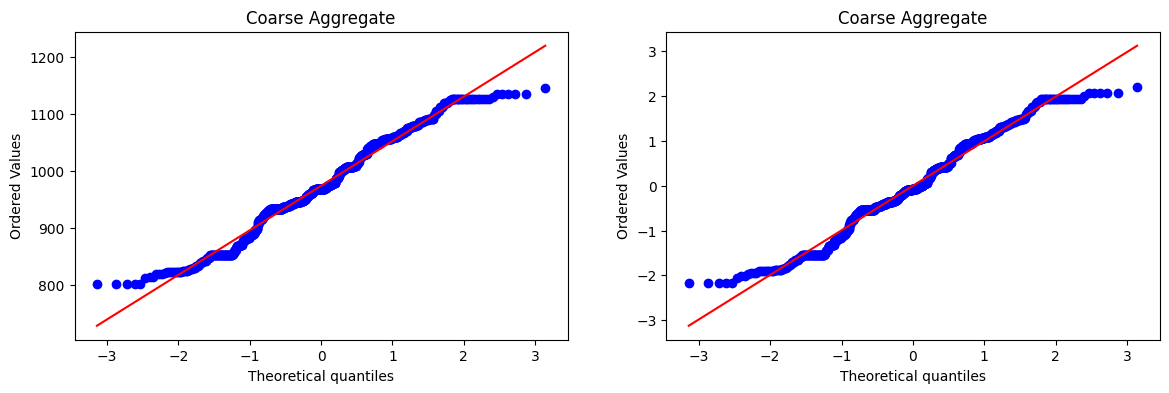

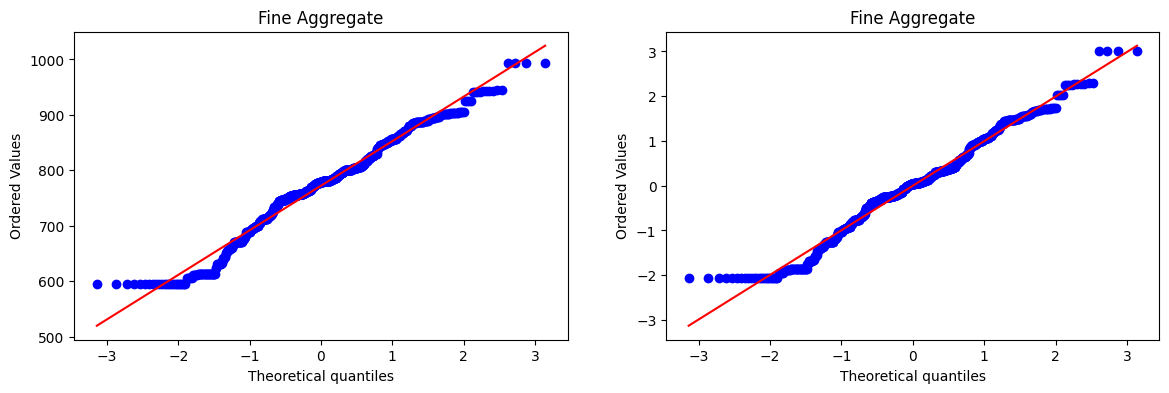

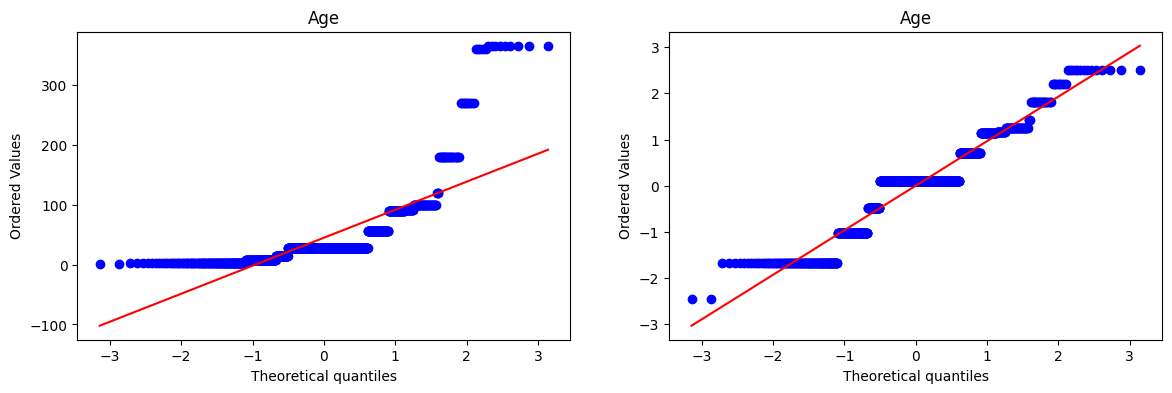

In [100]:
for col in x_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(x_train[col],dist='norm',plot=plt)

    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_transfromed_train[col],dist='norm',plot=plt)
    plt.title(col)


    plt.show()





In [124]:
pt1=PowerTransformer(method='yeo-johnson')

x_pt_train=pt1.fit_transform(x_train)
x_pt_test=pt1.transform(x_test)

lt=LinearRegression()
lt.fit(x_pt_train,y_train)

y_pred=lt.predict(x_pt_test)
r2_score(y_pred,y_test)
np.mean(cross_val_score(lt,x_pt_train,y_train, scoring='r2',cv=10))

pd.DataFrame({'col':x_train.columns,'yeo':pt1.lambdas_})

,col,yeo
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,FlyAsh,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [125]:
pd.DataFrame({'col':x_train.columns,'boc-cox':pt.lambdas_,'yeo':pt1.lambdas_})

,col,boc-cox,yeo
0,Cement,0.174348,0.174348
1,Blast Furnace Slag,0.015715,0.015715
2,FlyAsh,-0.161447,-0.161447
3,Water,0.771307,0.771307
4,Superplasticizer,0.253935,0.253935
5,Coarse Aggregate,1.130050,1.130050
6,Fine Aggregate,1.783100,1.783100
7,Age,0.019885,0.019885
